THIS IS PRACTICE FOR THE K-NN ALGORITHM WITH IRIS DATASET 

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter #doubtful about this
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo 
from matplotlib.colors import ListedColormap

Fetching the dataset and preprocessing it

In [3]:

def fetch_iris_data():
    # fetch dataset 
    iris = fetch_ucirepo(id=53) 
      
    # data (as pandas dataframes) 
    X = iris.data.features 
    y = iris.data.targets 
  
    # split data into training and testing datasets(80:20)
    x_train , x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # standardize datasets
    scaler =  StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)
  
    return X, y, x_train , x_test, y_train, y_test, X.columns.tolist(), y['class'].unique()


**Implementation of K-nearest neighbor**

references-
1. https://www.geeksforgeeks.org/python/
2. 

In [4]:
class KNN:
    def __init__(self, k, dist_metric):
        self.k = k
        self.dist_metric = dist_metric
       # self.weighted = weighted
       
    def fit(self, x_train, y_train):
        self.x_train = np.array(x_train)
        self.y_train = np.array(y_train).ravel()

    def cal_distance(self, x1, x2):
        if self.dist_metric == 'euclidean':
            return np.linalg.norm(x1 - x2)
        elif self.dist_metric == 'manhattan':
            return np.sum(np.abs(x1-x2))

    def predict_single_data_point(self, x):
        # Calculate distances to all training data sets
        distance = []
        for i, x_train in enumerate(self.x_train):
            dist =  self.cal_distance(x, x_train)
            distance.append((dist, self.y_train[i]))
        # sort
        distance.sort(key=lambda x: x[0])
        knn = distance[:self.k]

        # get labels of knn
       
        lbls = [label for _, label in knn]
        nearestNeighbour = Counter(lbls).most_common(1)
        return nearestNeighbour[0][0]

    def predict(self, x_test):
        x_test = np.array(x_test)
        return np.array([self.predict_single_data_point(x) for x in x_test])

    def checkAccuracy(self, x_test, y_test):
        predictions = self.predict(x_test)
        y_test_array = np.array(y_test).ravel()
        accuracy = np.mean(predictions == y_test_array)
        return accuracy
        
        

evaluate k-values

In [5]:
def evaluate_k_values(x_train, x_test, y_train, y_test, dist_metric, k_values):
    result = {}
    for k in k_values : 
        k_nn = KNN(k=k,dist_metric= dist_metric)
        k_nn.fit(x_train, y_train) 
        accuracy = k_nn.checkAccuracy(x_test, y_test)
        result[k] = accuracy
        print(f"Accuracy for k{k} = {accuracy}")
    return result

Plot graph

In [6]:
def accuracy_vs_k(accuracy, k):
    print(accuracy)
    acc =  np.array(list(accuracy.values()))
    
    plt.plot(k, acc)
    plt.xlabel('K-value')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs k-value')
    plt.show()
    

In [7]:
# Define function to predict for grid points (using your KNN)
def predict_grid(model, xx, yy):
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    preds = []
    for point in grid_points:
        # Calculate distances to all training points
        distances = [(model.cal_distance(point, x_train), model.y_train[i]) for i, x_train in enumerate(model.x_train)]
        distances.sort(key=lambda x: x[0])
        k_nearest = [label for (_, label) in distances[:model.k]]
        pred = max(set(k_nearest), key=k_nearest.count)
        preds.append(pred)
    return np.array(preds).reshape(xx.shape)

In [8]:
def train_data_for_two_features(X, y):
    x, y, x_train, x_test, y_train, y_test, feature_names, class_names = fetch_iris_data()

    # Use only the first two features
    x_train_2d = x_train[:, :2]
    
    # Create a mapping from string labels to integers
    class_to_int = {name: i for i, name in enumerate(class_names)}
    # CORRECTED LINE: Convert DataFrame to NumPy array before calling ravel()
    y_train_int = np.array([class_to_int[label] for label in y_train.values.ravel()])

    # Train your custom KNN model
    k = 5
    knn_model = KNN(k=k, dist_metric='euclidean')
    knn_model.fit(x_train_2d, y_train) 
    
    x_min, x_max = x_train_2d[:, 0].min() - 1, x_train_2d[:, 0].max() + 1
    y_min, y_max = x_train_2d[:, 1].min() - 1, x_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z_str = predict_grid(knn_model, xx, yy)
    Z_int = np.array([class_to_int[label] for label in Z_str.ravel()]).reshape(Z_str.shape)

    # Plot decision boundary
    plt.figure(figsize=(10, 6))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    
    plt.contourf(xx, yy, Z_int, cmap=cmap_light, alpha=0.6)
    plt.scatter(x_train_2d[:, 0], x_train_2d[:, 1], c=y_train_int, cmap=ListedColormap(cmap_bold), edgecolor='k', s=40)
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.show()

In [9]:
def create_decision_boundary_2d(X_train, X_test, y_train, y_test, feature_names, target_names, k1=1, k2=15):
    """
    Create decision boundary plots for 2D visualization.
    Uses custom k-NN implementation for all predictions.
    """
    class_to_int = {name: i for i, name in enumerate(target_names)}
    # CORRECTED LINES: Convert DataFrame to NumPy array before calling ravel()
    y_train_int = np.array([class_to_int[label] for label in y_train.values.ravel()])
    y_test_int = np.array([class_to_int[label] for label in y_test.values.ravel()])

    # ... (rest of the function is the same as before) ...
    
    feature_idx = [2, 3]
    selected_features = [feature_names[i] for i in feature_idx]
    
    X_train_2d = X_train[:, feature_idx]
    X_test_2d = X_test[:, feature_idx]
    
    h = 0.02
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for idx, k in enumerate([k1, k2]):
        knn_2d = KNN(k=k, dist_metric='euclidean')
        knn_2d.fit(X_train_2d, y_train)
        
        Z_str = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z_int = np.array([class_to_int[label] for label in Z_str.ravel()]).reshape(xx.shape)
        
        axes[idx].contourf(xx, yy, Z_int, alpha=0.8, cmap=plt.cm.RdYlBu)
        
        scatter = axes[idx].scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
                                   c=y_train_int, cmap=plt.cm.RdYlBu, 
                                   edgecolors='black', s=50)
        
        axes[idx].scatter(X_test_2d[:, 0], X_test_2d[:, 1], 
                         c=y_test_int, cmap=plt.cm.RdYlBu, 
                         edgecolors='white', s=100, marker='^', linewidth=2)
        
        axes[idx].set_xlabel(selected_features[0], fontsize=12)
        axes[idx].set_ylabel(selected_features[1], fontsize=12)
        axes[idx].set_title(f'Decision Boundary (k = {k})\\nUCI Iris Dataset', fontsize=14, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
    
    cbar = fig.colorbar(scatter, ax=axes, shrink=0.8)
    cbar.set_label('Class', fontsize=12)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(target_names)
    
    plt.suptitle('k-NN Decision Boundaries: High Variance vs High Bias\\n(UCI Iris Dataset - Custom Implementation)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Accuracy for k1 = 0.9666666666666667
Accuracy for k3 = 0.9333333333333333
Accuracy for k5 = 0.9333333333333333
Accuracy for k7 = 0.9666666666666667
Accuracy for k11 = 0.9666666666666667
Accuracy for k15 = 0.9666666666666667
{1: 0.9666666666666667, 3: 0.9333333333333333, 5: 0.9333333333333333, 7: 0.9666666666666667, 11: 0.9666666666666667, 15: 0.9666666666666667}


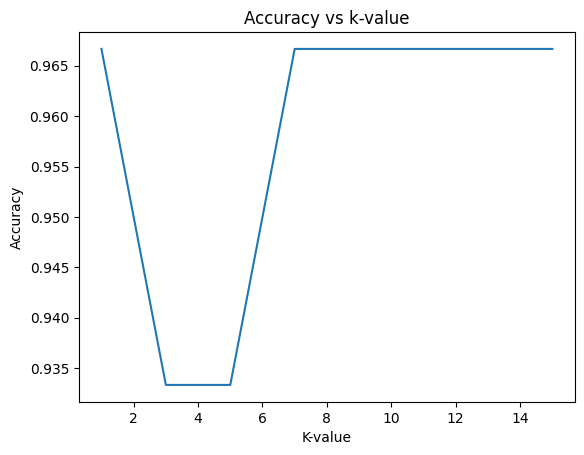

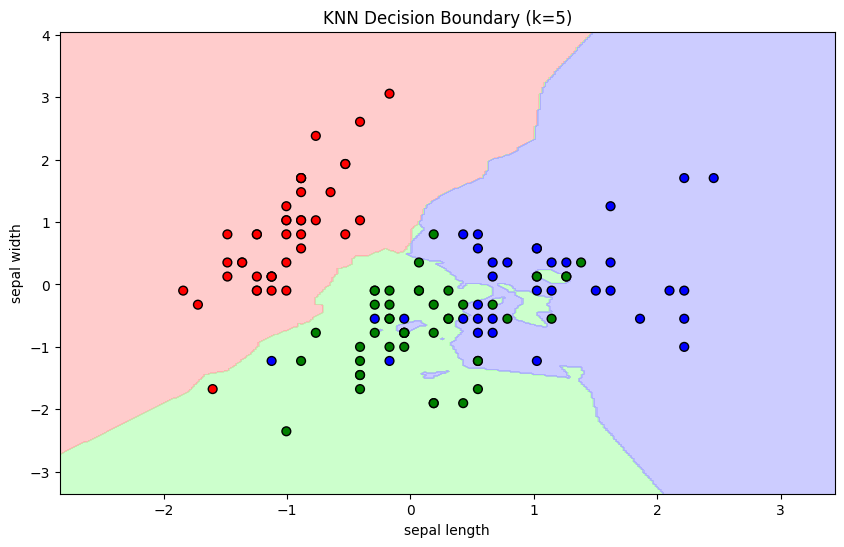

/tmp/ipykernel_13/3438716315.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


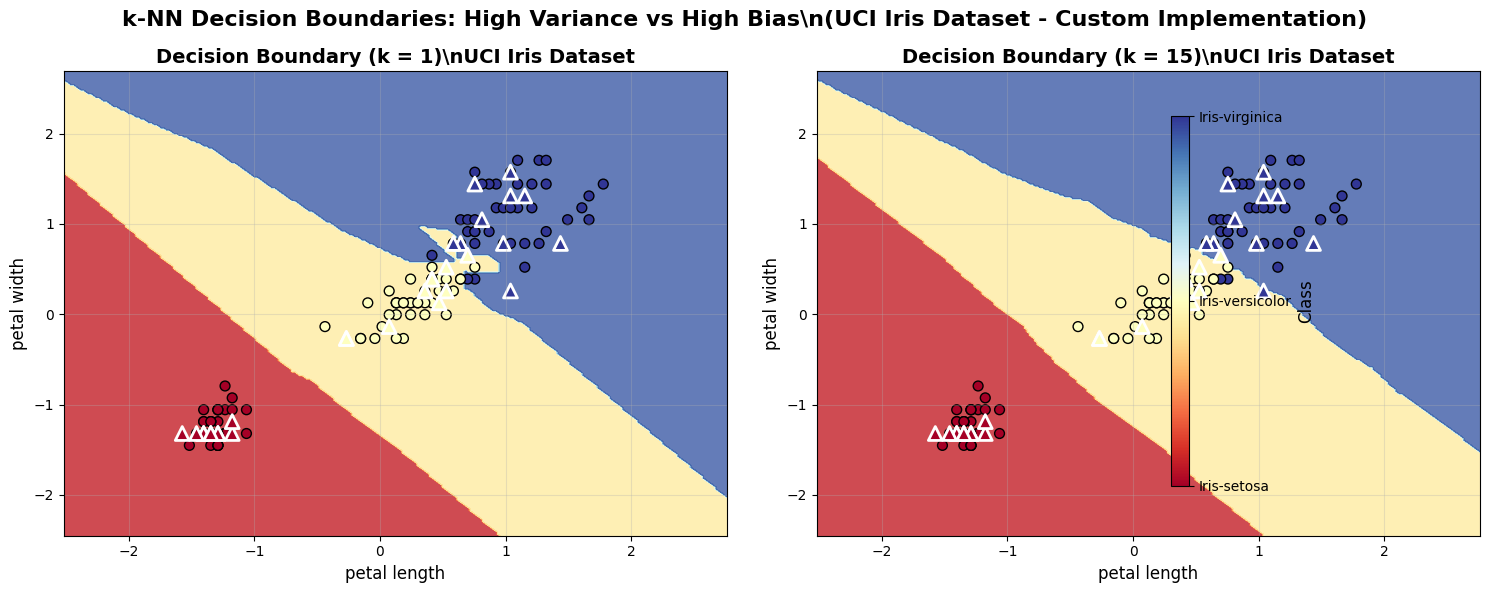

In [10]:
def main():
    x, y, x_train , x_test, y_train, y_test, feature, target = fetch_iris_data()
     # Define k values to test
    k_values = [1, 3, 5, 7, 11, 15]
    dist_metric = 'euclidean'
    res = evaluate_k_values(x_train, x_test, y_train, y_test, dist_metric, k_values)
    accuracy_vs_k(res, k_values)
    train_data_for_two_features(x,y)
    create_decision_boundary_2d(x_train, x_test, y_train, y_test, feature, target, k1=1, k2=15)
if __name__ == "__main__":
    main()